In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
import os
os.getcwd()

'C:\\Users\\ADMIN\\Documents'

In [4]:
import os
os.chdir("D:\\PythonData")

In [5]:
os.getcwd()

'D:\\PythonData'

In [6]:
apps_with_duplicates = pd.read_csv("apps.csv")

In [7]:
apps = apps_with_duplicates.drop_duplicates()
print('Total number of apps in the dataset : ', len(apps))
n = 5
apps.sample(n)

Total number of apps in the dataset :  9659


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
8529,9668,Free games: Masha and the Bear,FAMILY,4.3,34514,60.0,"5,000,000+",Free,0,Everyone,Puzzle;Brain Games,"July 20, 2018",1.2.8,4.1 and up
3986,4927,All Type Ac Repair & Services,LIFESTYLE,4.3,45,2.2,"10,000+",Free,0,Everyone,Lifestyle,"December 26, 2017",0.8,4.1 and up
2144,2718,Stocard - Rewards Cards Wallet,SHOPPING,4.6,284725,20.0,"10,000,000+",Free,0,Everyone,Shopping,"July 31, 2018",7.2.1,4.1 and up
3096,3878,Dog Sim Online: Raise a Family,FAMILY,4.6,94989,74.0,"5,000,000+",Free,0,Teen,Simulation,"April 22, 2018",8.6,4.0 and up
3128,3932,AutoCAD - DWG Viewer & Editor,PRODUCTIVITY,4.2,145088,24.0,"10,000,000+",Free,0,Everyone,Productivity,"July 23, 2018",4.5.19,4.4 and up


In [8]:
#clean the data
#remove the characters like + or , or $
chars_to_remove = ['+',',','$']
cols_to_clean = ['Installs','Price']
for col in cols_to_clean:
    for char in chars_to_remove:
        apps[col] = apps[col].apply(lambda x: x.replace(char,""))

print(apps.info())

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.0 MB
None


In [9]:
#convert the data types in Install and Price into numeric data types
apps['Installs'] = apps['Installs'].astype(float)
apps['Price'] = apps['Price'].astype(float)
print(apps.dtypes)

Unnamed: 0          int64
App                   str
Category              str
Rating            float64
Reviews             int64
Size              float64
Installs          float64
Type                  str
Price             float64
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object


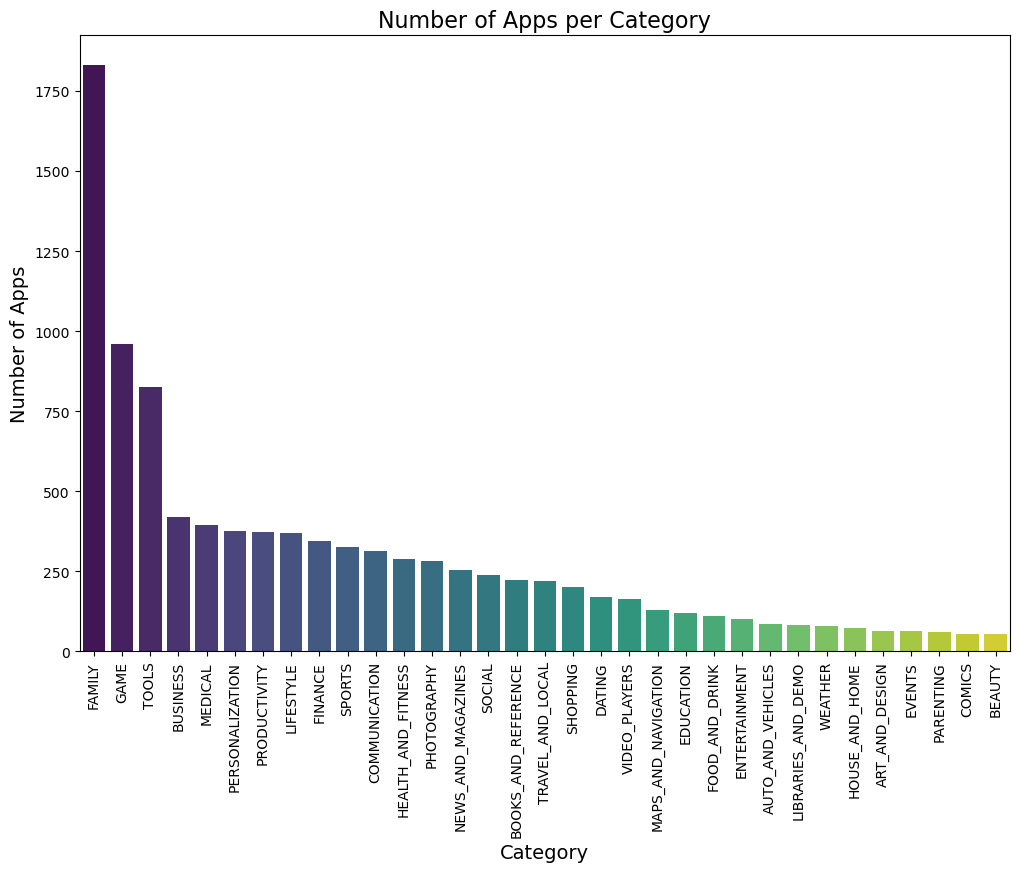

In [10]:
#explore the app categories: which category is the biggest in the market? Is any specific one dominating the market? Which is the most consolidated category?
nums_apps_category = apps['Category'].value_counts()
sorted_nums_apps_category = nums_apps_category.sort_values(ascending=False)
plt.figure(figsize = (12,8))
sns.barplot(x=sorted_nums_apps_category.index, y=sorted_nums_apps_category.values,hue=sorted_nums_apps_category.index,palette='viridis')
plt.title('Number of Apps per Category', fontsize = 16)
plt.xlabel('Category',fontsize = 14)
plt.ylabel('Number of Apps',fontsize = 14)
plt.xticks(rotation = 90)
plt.show()

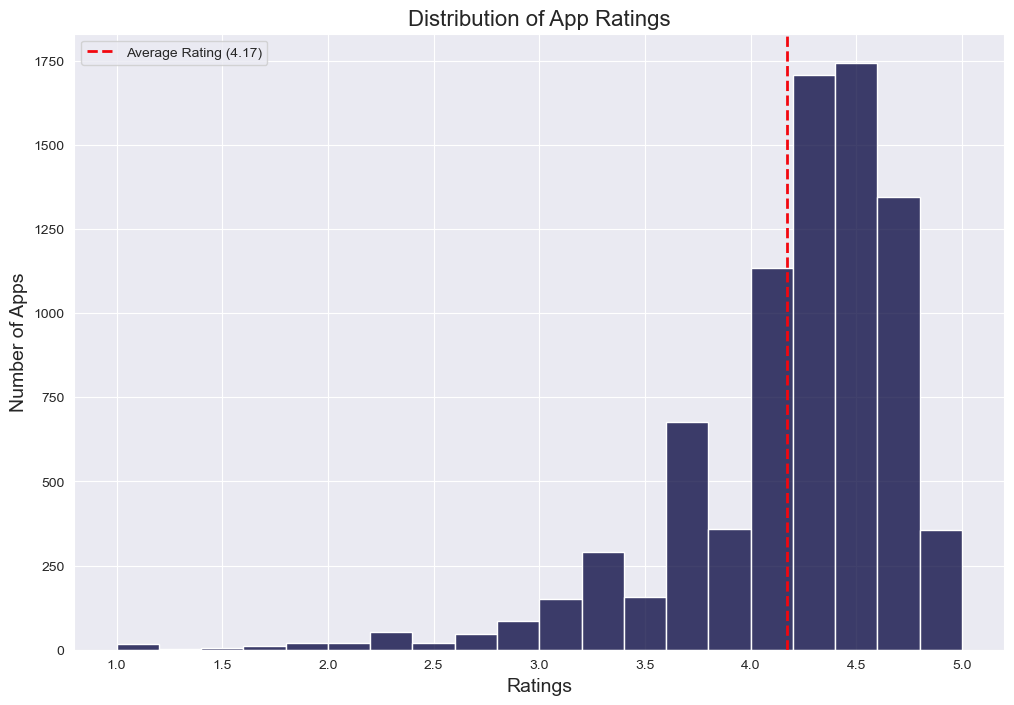

In [34]:
#check the ratings of the apps
avg_ratings = apps['Rating'].mean()
plt.figure(figsize=(12,8))
sns.histplot(apps['Rating'],bins=20,kde=False,color='#01013b')
plt.axvline(avg_ratings, color='#f2070f',linestyle='--',linewidth=2,label=f'Average Rating ({avg_ratings:.2f})')
plt.title('Distribution of App Ratings', fontsize = 16)
plt.xlabel('Ratings',fontsize=14)
plt.ylabel('Number of Apps',fontsize=14)
plt.legend()
plt.show()

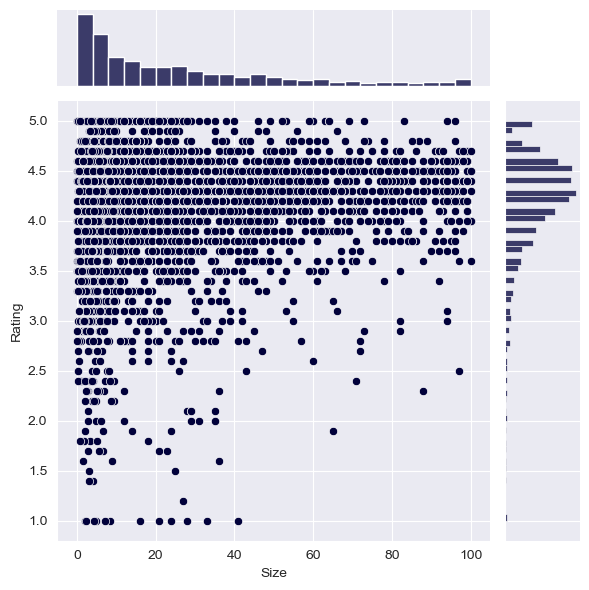

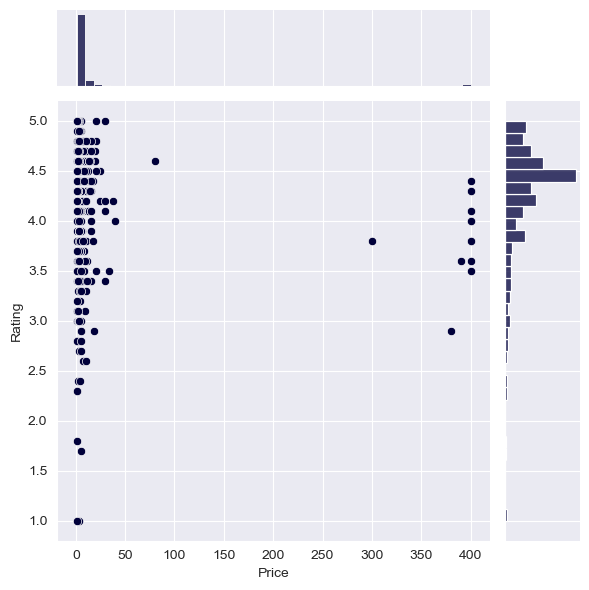

In [24]:
#size and price of apps
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')
apps_size_ratings = apps[(~apps['Rating'].isnull()) & (~apps['Size'].isnull())]
large_cat = apps_size_ratings.groupby(['Category']).filter(lambda x: len(x) >= 250)
plt1 = sns.jointplot(x = large_cat['Size'], y = large_cat['Rating'], color = '#01013b')
paid_apps = apps_size_ratings[apps_size_ratings['Type'] == 'Paid']
plt2 = sns.jointplot (x = paid_apps['Price'], y = paid_apps['Rating'],color = '#01013b')

,Category,App,Price
3327,FAMILY,most expensive app (H),399.99
3465,LIFESTYLE,💎 I'm rich,399.99
3469,LIFESTYLE,I'm Rich - Trump Edition,400.00
4396,LIFESTYLE,I am rich,399.99
4398,FAMILY,I am Rich Plus,399.99
4399,LIFESTYLE,I am rich VIP,299.99
4400,FINANCE,I Am Rich Premium,399.99
4401,LIFESTYLE,I am extremely Rich,379.99
4402,FINANCE,I am Rich!,399.99
4403,FINANCE,I am rich(premium),399.99


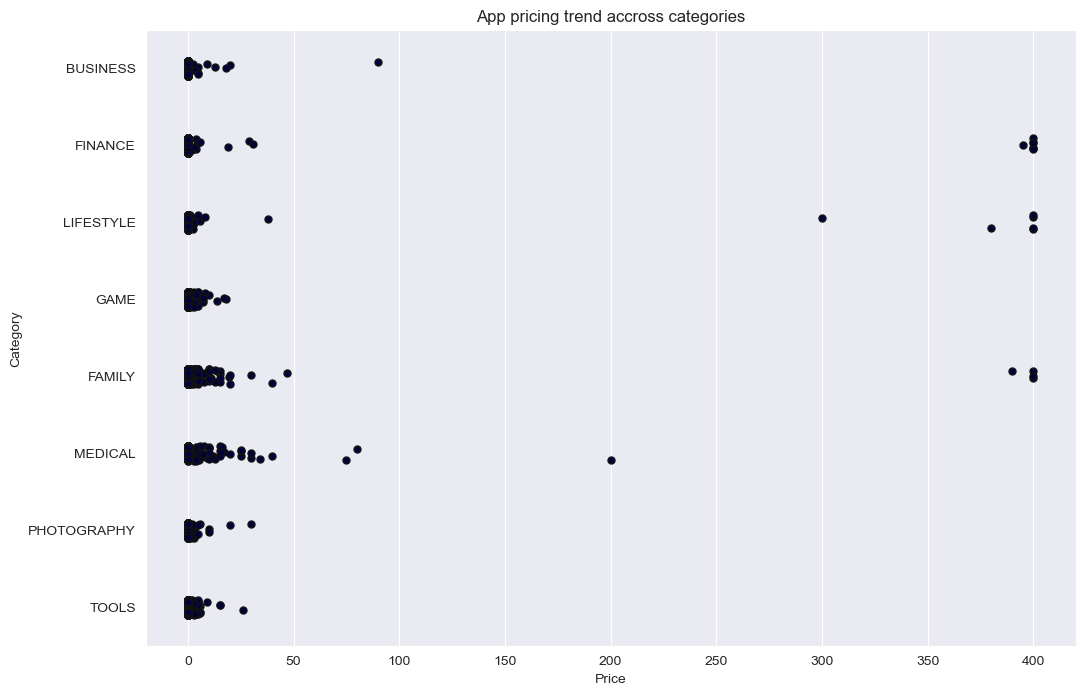

In [29]:
fig, ax = plt.subplots()
fig.set_size_inches(12,8)

popular_cat = apps[apps.Category.isin(['GAME','FAMILY','PHOTOGRAPHY','MEDICAL','TOOLS','FINANCE','LIFESTYLE','BUSINESS'])]
ax = sns.stripplot(x=popular_cat['Price'],y=popular_cat['Category'],jitter=True,linewidth=1, color='#01013b')
ax.set_title('App pricing trend accross categories')

above_200 = popular_cat[popular_cat['Price'] > 200]
above_200[['Category','App','Price']]

Text(0.5, 1.0, 'App pricing trend across categories after filtering for junk apps')

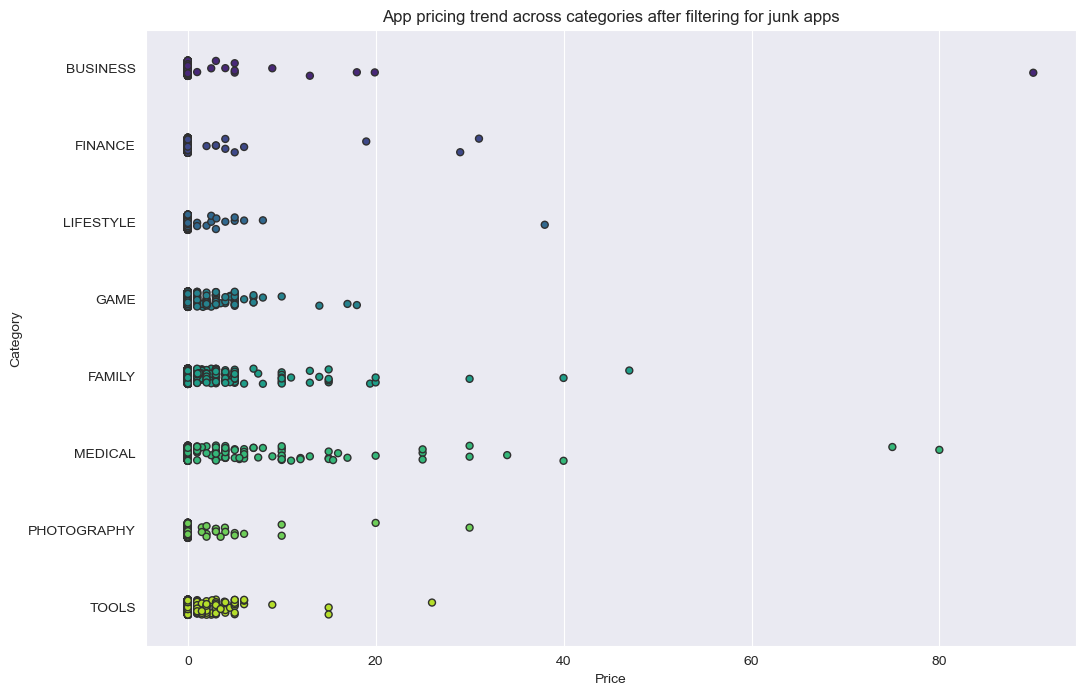

In [32]:
apps_under_100 = popular_cat[popular_cat['Price'] < 100]
fig, ax = plt.subplots()
fig.set_size_inches(12,8)
ax = sns.stripplot(x = 'Price', y = 'Category', data = apps_under_100, jitter = True, linewidth = 1, hue = 'Category', palette='viridis')
ax.set_title('App pricing trend across categories after filtering for junk apps')

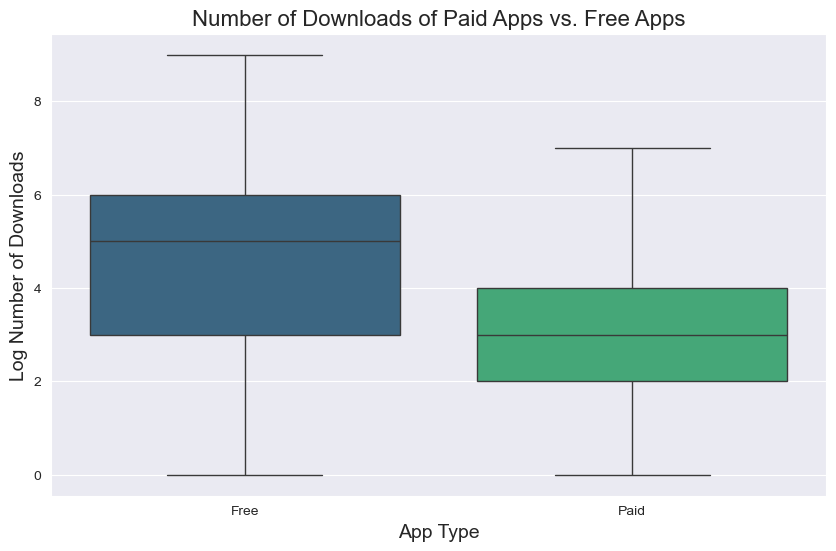

In [35]:
filtered_apps = apps[apps['Installs'] > 0].copy()
filtered_apps.loc[:,'Log_Installs'] = np.log10(filtered_apps['Installs'])
plt.figure(figsize=(10,6))
sns.boxplot(x='Type', y='Log_Installs',data=filtered_apps,hue='Type',palette='viridis')
plt.title('Number of Downloads of Paid Apps vs. Free Apps',fontsize = 16)
plt.xlabel('App Type',fontsize = 14)
plt.ylabel('Log Number of Downloads',fontsize = 14)
plt.show()

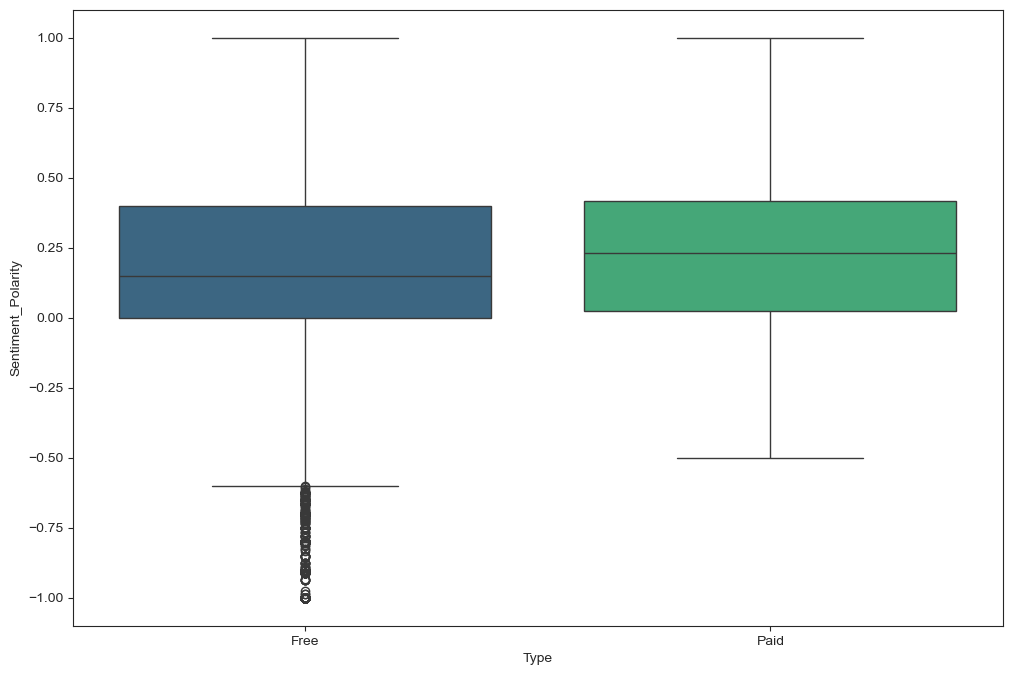

In [38]:
reviews_df = pd.read_csv('user_reviews.csv')
merged_df = pd.merge(apps,reviews_df,on = 'App')
merged_df = merged_df.dropna(subset = ['Sentiment','Review'])
sns.set_style('ticks')
fig, ax = plt.subplots()
fig.set_size_inches(12,8)
ax = sns.boxplot(x = 'Type',y='Sentiment_Polarity',data = merged_df,hue='Type',palette='viridis')
ax.set_title=('Sentiment Polarity Distribution')